In [1]:
import pandas as pd
from sklearn.datasets import load_diabetes

In [2]:
data = load_diabetes(as_frame=True)
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [3]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.33, random_state=42)

### First Lets use the sklearn Lib to implement Linear Regression `Before Going for the Regularisation i.e Ridge`

#### 1. sklearn.linear_model.LinearRegression

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error,r2_score

LR = LinearRegression()

LR.fit(x_train,y_train)

y_pred = LR.predict(x_test)

rmse = root_mean_squared_error(y_test,y_pred)

r2 = r2_score(y_test,y_pred)

print("RSME : ",rmse)
print("R2 : ",r2)

RSME :  53.083032102749975
R2 :  0.5103942572821251


#### 1. sklearn.linear_model.Ridge

In [5]:
from sklearn.linear_model import Ridge

RD = Ridge(alpha=0.00001)

RD.fit(x_train,y_train)

y_pred = RD.predict(x_test)

rmse = root_mean_squared_error(y_test,y_pred)

r2 = r2_score(y_test,y_pred)

print("RSME : ",rmse)
print("R2 : ",r2)

RSME :  53.08330499087714
R2 :  0.5103892233595209


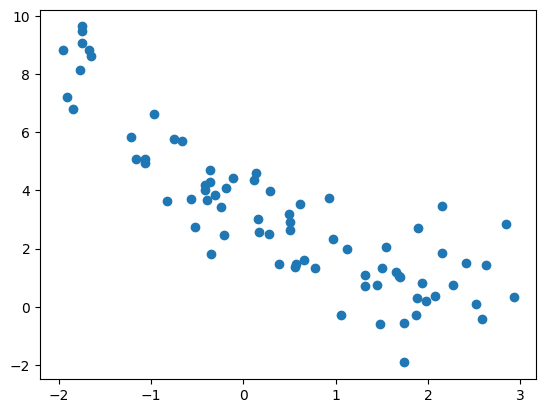

In [6]:
import numpy as np
import matplotlib.pyplot as plt
m = 75
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.53 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show()

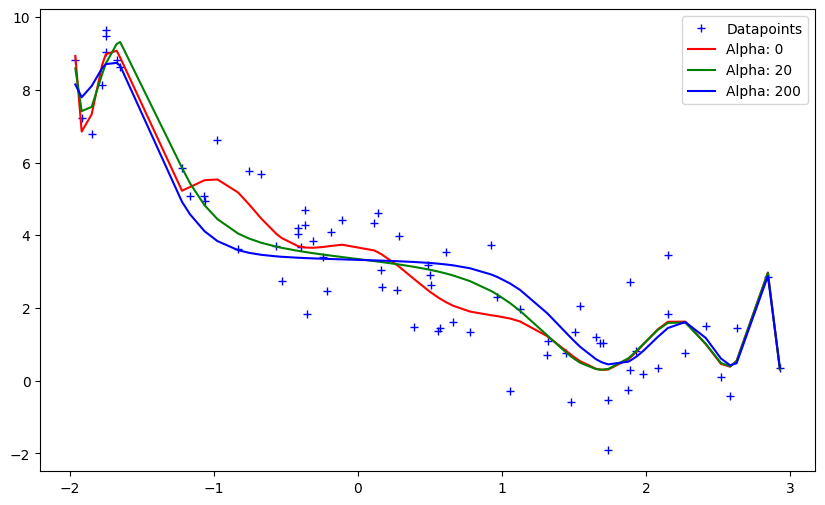

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1, x2, alpha):
    model = Pipeline([
        ('poly_feats', PolynomialFeatures(degree=16)),
        ('ridge', Ridge(alpha=alpha))
    ])
    model.fit(x1, x2)
    return model.predict(x1)

alphas = [0, 20, 200]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha, c in zip(alphas, cs):
    preds = get_preds_ridge(x1, x2, alpha)
    # Plot
    plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))

plt.legend()
plt.show()

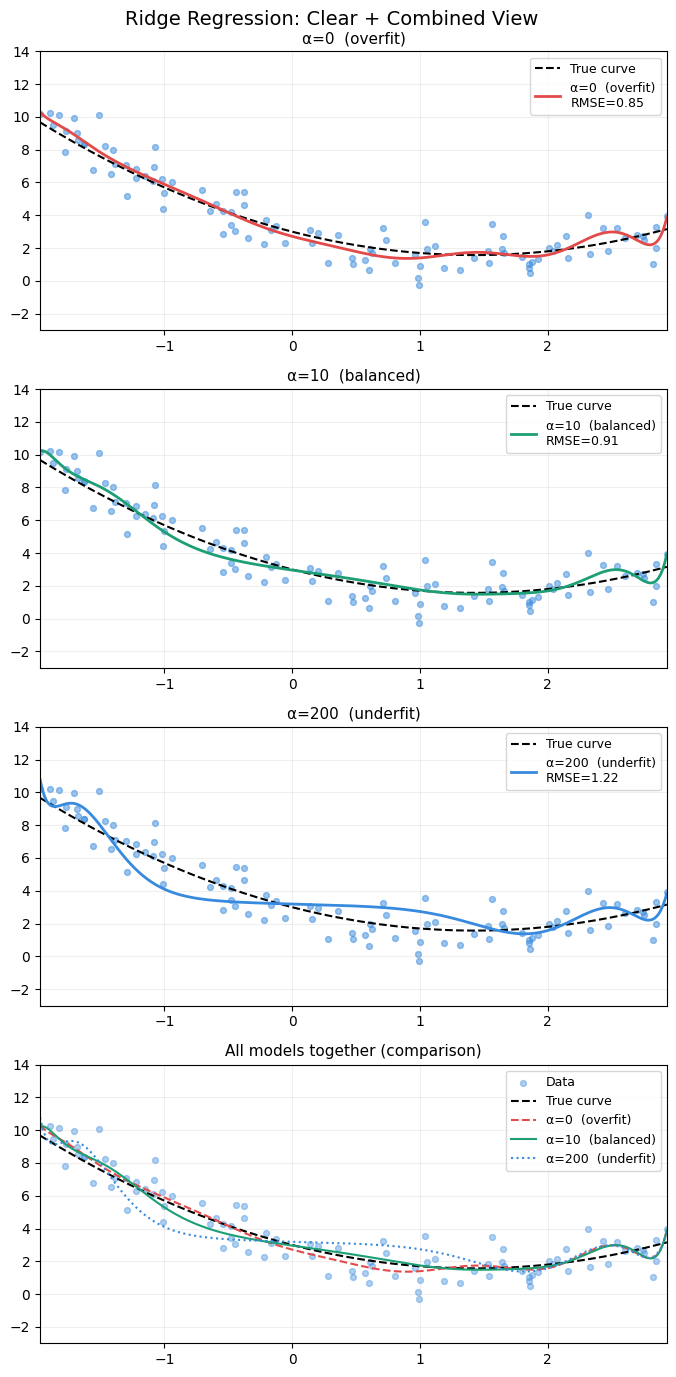

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

# ── Data generation ──────────────────────────────────────────────────────────
np.random.seed(42)
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1**2 - 2 * x1 + 3 + np.random.randn(m, 1)

x_plot = np.linspace(x1.min(), x1.max(), 300).reshape(-1, 1)
x_true = 0.7 * x_plot**2 - 2 * x_plot + 3   # noise-free ground truth

# ── Fit models ────────────────────────────────────────────────────────────────
alphas      = [0, 10, 200]
labels      = ["α=0  (overfit)", "α=10  (balanced)", "α=200  (underfit)"]
colors      = ["#E24B4A", "#1D9E75", "#378ADD"]
line_styles = ["--", "-", ":"]

def fit_ridge(x1, x2, alpha):
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=16, include_bias=True)),
        ("ridge", Ridge(alpha=alpha))
    ])
    model.fit(x1, x2)
    preds_curve = model.predict(x_plot)
    preds_train = model.predict(x1)
    rmse = np.sqrt(mean_squared_error(x2, preds_train))
    return preds_curve, rmse

# ── Plot ──────────────────────────────────────────────────────────────────────
# ── Combined + Separate Visualization ─────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(7, 14))

# ── Top 3: individual plots ───────────────────────────────────────────────────
for ax, alpha, label, color in zip(axes[:3], alphas, labels, colors):
    preds_curve, rmse = fit_ridge(x1, x2, alpha)

    ax.scatter(x1, x2, s=18, alpha=0.5, color="#378ADD")
    ax.plot(x_plot, x_true, color="black", linestyle="--", label="True curve")
    ax.plot(x_plot, preds_curve, color=color, linewidth=2,
            label=f"{label}\nRMSE={rmse:.2f}")

    ax.set_title(label, fontsize=11)
    ax.set_xlim(x1.min(), x1.max())
    ax.set_ylim(-3, 14)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.2)

# ── Bottom: all together ──────────────────────────────────────────────────────
ax = axes[3]

ax.scatter(x1, x2, s=18, alpha=0.4, color="#378ADD", label="Data")
ax.plot(x_plot, x_true, color="black", linestyle="--", label="True curve")

for alpha, label, color, ls in zip(alphas, labels, colors, line_styles):
    preds_curve, rmse = fit_ridge(x1, x2, alpha)
    ax.plot(x_plot, preds_curve, color=color, linestyle=ls,
            label=f"{label}")

ax.set_title("All models together (comparison)", fontsize=11)
ax.set_xlim(x1.min(), x1.max())
ax.set_ylim(-3, 14)
ax.legend(fontsize=9)
ax.grid(alpha=0.2)

plt.suptitle("Ridge Regression: Clear + Combined View", fontsize=14)
plt.tight_layout()
plt.show()